In [6]:
# ============================================================================
# EDA COMPLETO - CON MANEJO DE DATOS PEQUEÑOS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, pearsonr, spearmanr
import warnings
import os
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

In [7]:


# ============================================================================
# 0. CARGAR ARCHIVOS (usando tus rutas)
# ============================================================================

print("="*80)
print("CARGANDO ARCHIVOS")
print("="*80)

# Usar rutas absolutas
logistica_path = r"C:\Users\leona\Desktop\MachineLearning\Machine-learning\data\processed\Dataset_ALDIMI_Logistica_Enriquecido.csv"
gravedad_path = r"C:\Users\leona\Desktop\MachineLearning\Machine-learning\data\processed\Dataset_ALDIMI_GravedadPaciente_Enriquecido.csv"

df_logistica = pd.read_csv(logistica_path)
df_gravedad = pd.read_csv(gravedad_path)

print(f"✅ Logística: {df_logistica.shape[0]} filas, {df_logistica.shape[1]} columnas")
print(f"✅ Gravedad: {df_gravedad.shape[0]} filas, {df_gravedad.shape[1]} columnas")
print("="*80)


CARGANDO ARCHIVOS
✅ Logística: 91250 filas, 11 columnas
✅ Gravedad: 3000 filas, 29 columnas


In [10]:
# ============================================================================
# 1. PRUEBA DE NORMALIDAD DE SHAPIRO-WILK (CORREGIDA CON MUESTREO)
# ============================================================================

print("\n" + "="*80)
print("PRUEBA DE NORMALIDAD DE SHAPIRO-WILK")
print("="*80)

def shapiro_test(df, dataset_name, columns=None, sample_size=5000):
    """
    Aplica prueba de Shapiro-Wilk a las columnas numéricas.
    Si el dataset es muy grande (>5000), toma una muestra aleatoria.
    """
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    results = []
    for col in columns:
        data = df[col].dropna()
        n_total = len(data)
        
        # Si es muy grande, tomar muestra
        if n_total > 5000:
            data_sample = data.sample(n=sample_size, random_state=42)
            n_used = sample_size
            muestreado = " (muestra)"
        else:
            data_sample = data
            n_used = n_total
            muestreado = ""
        
        # Shapiro necesita entre 3 y 5000 muestras
        if len(data_sample) >= 3 and len(data_sample) <= 5000:
            try:
                stat, p_value = shapiro(data_sample)
                normal = "✅ Sí" if p_value > 0.05 else "❌ No"
                
                # Interpretación
                if p_value > 0.05:
                    interpretacion = "Distribución normal"
                elif p_value > 0.01:
                    interpretacion = "Ligera desviación"
                else:
                    interpretacion = "No normal"
                
                results.append({
                    'Variable': col,
                    'n_total': n_total,
                    'n_usado': n_used,
                    'Muestra': muestreado if n_total > 5000 else "Completo",
                    'Estadístico W': round(stat, 4),
                    'p-valor': round(p_value, 4),
                    '¿Normal?': normal,
                    'Interpretación': interpretacion
                })
            except Exception as e:
                print(f"⚠️ Error en {col}: {e}")
        else:
            print(f"⚠️ {col}: No se puede aplicar Shapiro (n={len(data_sample)})")
    
    return pd.DataFrame(results)

# Identificar columnas numéricas
log_numeric = df_logistica.select_dtypes(include=[np.number]).columns.tolist()
grav_numeric = df_gravedad.select_dtypes(include=[np.number]).columns.tolist()

# Prueba para Logística (con muestreo)
print("\n📊 LOGÍSTICA ENRIQUECIDO:")
print(f"Variables numéricas: {log_numeric}")
print(f"Tamaño del dataset: {len(df_logistica):,} filas")
print(f"Usando muestra de 5,000 para Shapiro (dataset grande)")
shapiro_log = shapiro_test(df_logistica, "Logística", log_numeric, sample_size=5000)
if not shapiro_log.empty:
    print(shapiro_log.to_string(index=False))
else:
    print("⚠️ No se pudo realizar la prueba")

# Prueba para Gravedad
print("\n📊 GRAVEDAD PACIENTE ENRIQUECIDO:")
print(f"Variables numéricas: {grav_numeric}")
print(f"Tamaño del dataset: {len(df_gravedad):,} filas")
shapiro_grav = shapiro_test(df_gravedad, "Gravedad", grav_numeric, sample_size=5000)
if not shapiro_grav.empty:
    print(shapiro_grav.to_string(index=False))
else:
    print("⚠️ No se pudo realizar la prueba")

print("\n" + "="*80)


PRUEBA DE NORMALIDAD DE SHAPIRO-WILK

📊 LOGÍSTICA ENRIQUECIDO:
Variables numéricas: ['Stock_Actual', 'Consumo_Diario', 'Lead_Time', 'Ocupacion_Albergue', 'Pacientes_Alto_Riesgo', 'Ocupacion_Total', 'Punto_Reorden', 'Ratio_Stock', 'Necesita_Reabastecimiento']
Tamaño del dataset: 91,250 filas
Usando muestra de 5,000 para Shapiro (dataset grande)
                 Variable  n_total  n_usado    Muestra  Estadístico W  p-valor ¿Normal?      Interpretación
             Stock_Actual    91250     5000  (muestra)         0.9874   0.0000     ❌ No           No normal
           Consumo_Diario    91250     5000  (muestra)         0.9997   0.6243     ✅ Sí Distribución normal
                Lead_Time    91250     5000  (muestra)         0.9323   0.0000     ❌ No           No normal
       Ocupacion_Albergue    91250     5000  (muestra)         0.8155   0.0000     ❌ No           No normal
    Pacientes_Alto_Riesgo    91250     5000  (muestra)         0.0961   0.0000     ❌ No           No normal
     

In [11]:

# ============================================================================
# 2. RESUMEN DE NORMALIDAD (CORREGIDO)
# ============================================================================

print("\n" + "="*80)
print("RESUMEN DE NORMALIDAD")
print("="*80)

def resumen_normalidad(df_results, dataset_name):
    """Genera un resumen de los resultados de normalidad"""
    if df_results.empty:
        print(f"No hay resultados para {dataset_name}")
        return
    
    normales = df_results[df_results['¿Normal?'] == '✅ Sí']
    no_normales = df_results[df_results['¿Normal?'] == '❌ No']
    
    print(f"\n📊 {dataset_name}:")
    print(f"  • Total variables analizadas: {len(df_results)}")
    print(f"  • Variables con distribución normal: {len(normales)}")
    print(f"  • Variables con distribución NO normal: {len(no_normales)}")
    
    if len(normales) > 0:
        print(f"\n  ✅ Variables NORMALES:")
        for _, row in normales.iterrows():
            print(f"    - {row['Variable']} (W={row['Estadístico W']:.4f}, p={row['p-valor']:.4f})")
    
    if len(no_normales) > 0:
        print(f"\n  ❌ Variables NO NORMALES:")
        for _, row in no_normales.head(10).iterrows():
            print(f"    - {row['Variable']} (W={row['Estadístico W']:.4f}, p={row['p-valor']:.4f})")
        if len(no_normales) > 10:
            print(f"    ... y {len(no_normales) - 10} variables más")
    
    # Recomendación
    print(f"\n  📌 RECOMENDACIÓN:")
    if len(no_normales) > len(normales):
        print("     Usar pruebas NO paramétricas (Spearman, Mann-Whitney U, Kruskal-Wallis)")
    else:
        print("     Puedes usar pruebas paramétricas (Pearson, t-test, ANOVA)")

# Generar resúmenes
resumen_normalidad(shapiro_log, "Logística Enriquecido")
resumen_normalidad(shapiro_grav, "Gravedad Paciente Enriquecido")

print("\n" + "="*80)


RESUMEN DE NORMALIDAD

📊 Logística Enriquecido:
  • Total variables analizadas: 9
  • Variables con distribución normal: 2
  • Variables con distribución NO normal: 7

  ✅ Variables NORMALES:
    - Consumo_Diario (W=0.9997, p=0.6243)
    - Ocupacion_Total (W=1.0000, p=1.0000)

  ❌ Variables NO NORMALES:
    - Stock_Actual (W=0.9874, p=0.0000)
    - Lead_Time (W=0.9323, p=0.0000)
    - Ocupacion_Albergue (W=0.8155, p=0.0000)
    - Pacientes_Alto_Riesgo (W=0.0961, p=0.0000)
    - Punto_Reorden (W=0.9603, p=0.0000)
    - Ratio_Stock (W=0.7292, p=0.0000)
    - Necesita_Reabastecimiento (W=0.8087, p=0.0000)

  📌 RECOMENDACIÓN:
     Usar pruebas NO paramétricas (Spearman, Mann-Whitney U, Kruskal-Wallis)

📊 Gravedad Paciente Enriquecido:
  • Total variables analizadas: 25
  • Variables con distribución normal: 0
  • Variables con distribución NO normal: 25

  ❌ Variables NO NORMALES:
    - Patient_ID (W=0.9549, p=0.0000)
    - Age (W=0.9955, p=0.0000)
    - Gender (W=0.6364, p=0.0000)
    - 


MATRIZ DE COVARIANZA

📊 MATRIZ DE COVARIANZA - LOGÍSTICA:


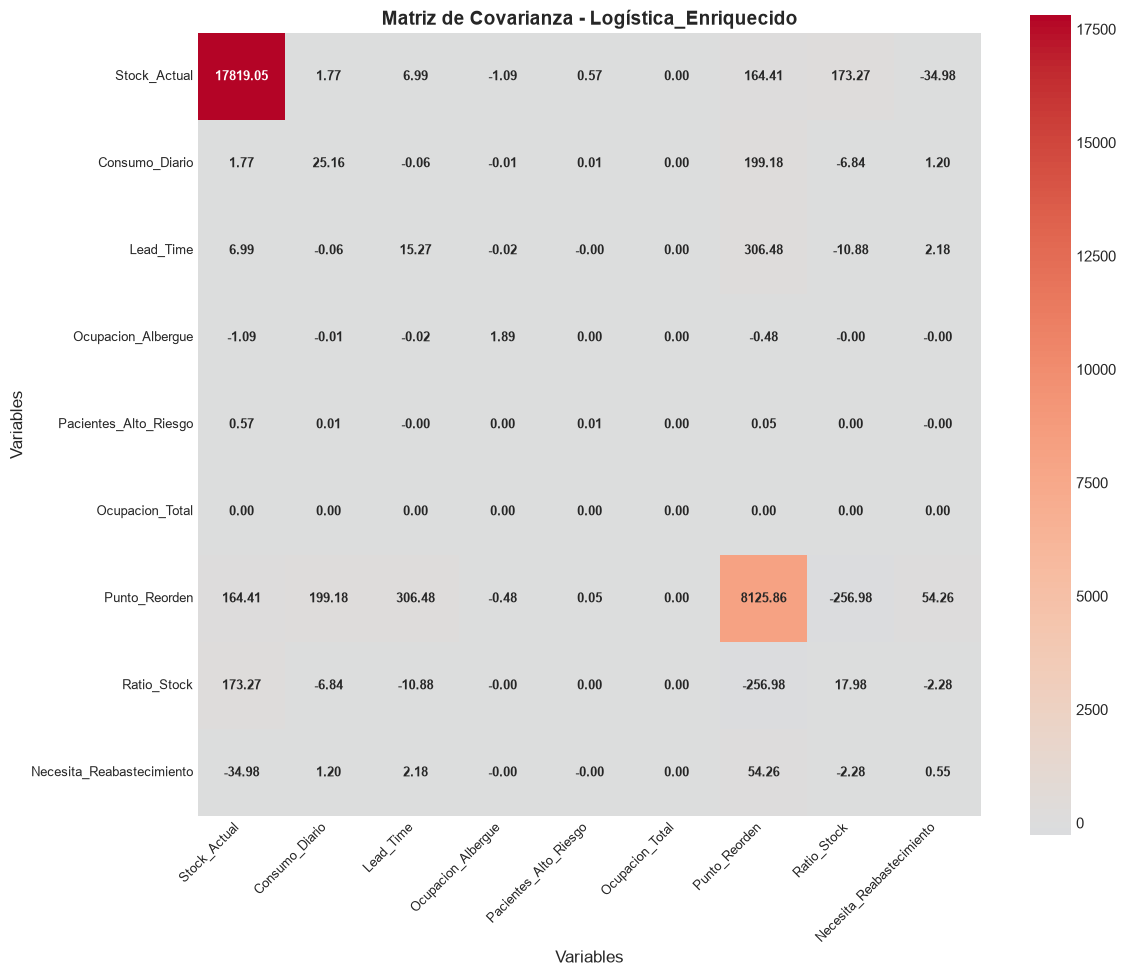


Matriz de Covarianza (primeras 10 variables):
                           Stock_Actual  Consumo_Diario  Lead_Time  \
Stock_Actual                   17819.05            1.77       6.99   
Consumo_Diario                     1.77           25.16      -0.06   
Lead_Time                          6.99           -0.06      15.27   
Ocupacion_Albergue                -1.09           -0.01      -0.02   
Pacientes_Alto_Riesgo              0.57            0.01      -0.00   
Ocupacion_Total                    0.00            0.00       0.00   
Punto_Reorden                    164.41          199.18     306.48   
Ratio_Stock                      173.27           -6.84     -10.88   
Necesita_Reabastecimiento        -34.98            1.20       2.18   

                           Ocupacion_Albergue  Pacientes_Alto_Riesgo  \
Stock_Actual                            -1.09                   0.57   
Consumo_Diario                          -0.01                   0.01   
Lead_Time                           

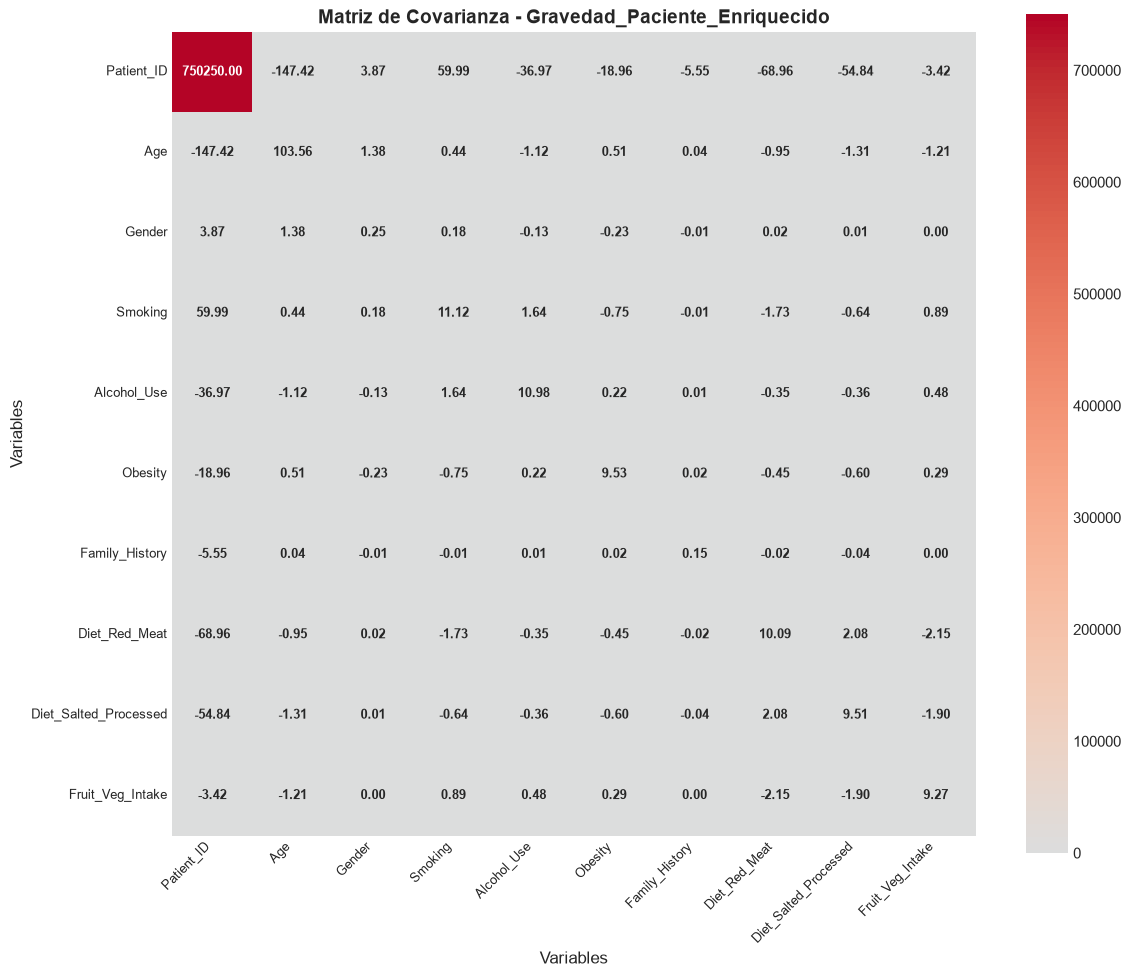


Matriz de Covarianza (primeras 10 variables):
                        Patient_ID       Age  Gender  Smoking  Alcohol_Use  \
Patient_ID             750250.0000 -147.4223  3.8733  59.9882     -36.9733   
Age                      -147.4223  103.5609  1.3754   0.4402      -1.1230   
Gender                      3.8733    1.3754  0.2499   0.1765      -0.1306   
Smoking                    59.9882    0.4402  0.1765  11.1212       1.6352   
Alcohol_Use               -36.9733   -1.1230 -0.1306   1.6352      10.9754   
Obesity                   -18.9560    0.5121 -0.2328  -0.7496       0.2228   
Family_History             -5.5458    0.0385 -0.0077  -0.0149       0.0082   
Diet_Red_Meat             -68.9617   -0.9543  0.0162  -1.7289      -0.3498   
Diet_Salted_Processed     -54.8389   -1.3126  0.0099  -0.6353      -0.3607   
Fruit_Veg_Intake           -3.4186   -1.2060  0.0021   0.8924       0.4836   

                       Obesity  Family_History  Diet_Red_Meat  \
Patient_ID            -18.956

In [13]:

# ============================================================================
# 2. MATRIZ DE COVARIANZA
# ============================================================================

print("\n" + "="*80)
print("MATRIZ DE COVARIANZA")
print("="*80)

def plot_covariance_matrix(df, title, columns=None, max_cols=10):
    """Genera y visualiza la matriz de covarianza"""
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Limitar a max_cols para visualización
    if len(columns) > max_cols:
        columns = columns[:max_cols]
        print(f"⚠️ Mostrando solo {max_cols} variables para visualización")
    
    cov_matrix = df[columns].cov()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax, 
                annot_kws={'size': 9, 'weight': 'bold'})
    ax.set_title(f'Matriz de Covarianza - {title}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Variables', fontsize=12)
    ax.set_ylabel('Variables', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(f'covarianza_{title.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return cov_matrix

# Covarianza para Logística
print("\n📊 MATRIZ DE COVARIANZA - LOGÍSTICA:")
cov_log = plot_covariance_matrix(df_logistica, "Logística_Enriquecido", log_numeric)
print("\nMatriz de Covarianza (primeras 10 variables):")
print(cov_log.round(2))

# Covarianza para Gravedad
print("\n📊 MATRIZ DE COVARIANZA - GRAVEDAD:")
cov_grav = plot_covariance_matrix(df_gravedad, "Gravedad_Paciente_Enriquecido", grav_numeric, max_cols=10)
print("\nMatriz de Covarianza (primeras 10 variables):")
print(cov_grav.round(4))



MATRIZ DE CORRELACIÓN CON VALORES NUMÉRICOS

📊 CORRELACIÓN DE SPEARMAN - LOGÍSTICA:


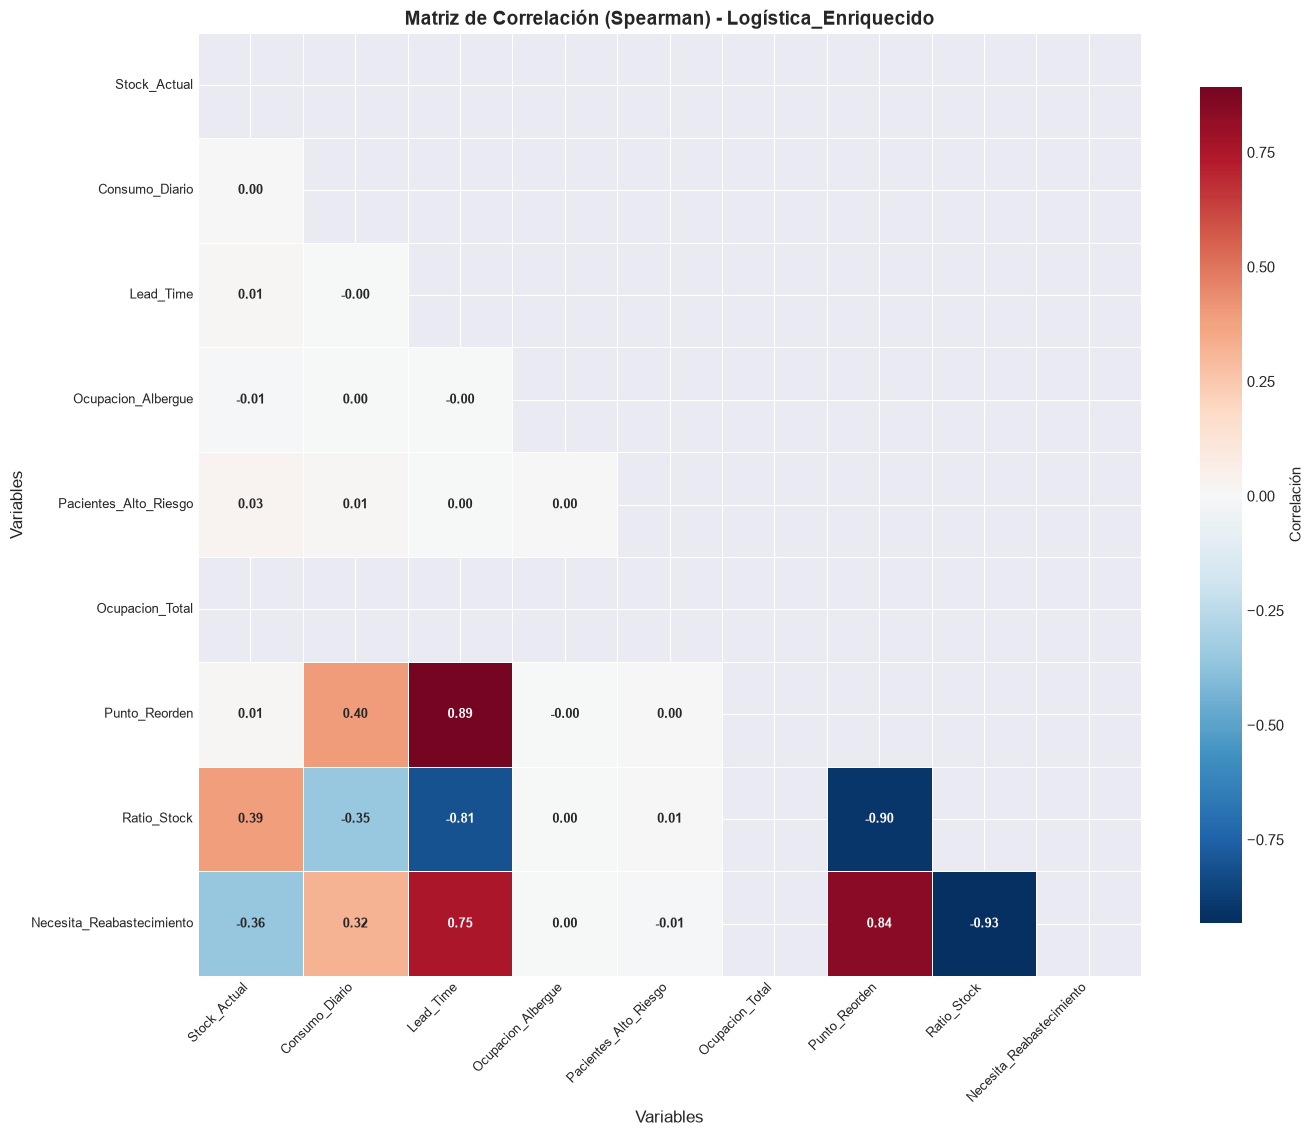


📝 CORRELACIONES MÁS FUERTES EN Logística_Enriquecido:
--------------------------------------------------
  • Necesita_Reabastecimiento ↔ Ratio_Stock: negativa Muy fuerte (r=0.931)
  • Ratio_Stock ↔ Necesita_Reabastecimiento: negativa Muy fuerte (r=0.931)
  • Ratio_Stock ↔ Punto_Reorden: negativa Muy fuerte (r=0.902)
  • Punto_Reorden ↔ Ratio_Stock: negativa Muy fuerte (r=0.902)
  • Lead_Time ↔ Punto_Reorden: positiva Muy fuerte (r=0.893)
  • Punto_Reorden ↔ Lead_Time: positiva Muy fuerte (r=0.893)
  • Punto_Reorden ↔ Necesita_Reabastecimiento: positiva Muy fuerte (r=0.837)
  • Necesita_Reabastecimiento ↔ Punto_Reorden: positiva Muy fuerte (r=0.837)

📊 CORRELACIÓN DE SPEARMAN - GRAVEDAD:
⚠️ Mostrando solo 10 variables para visualización


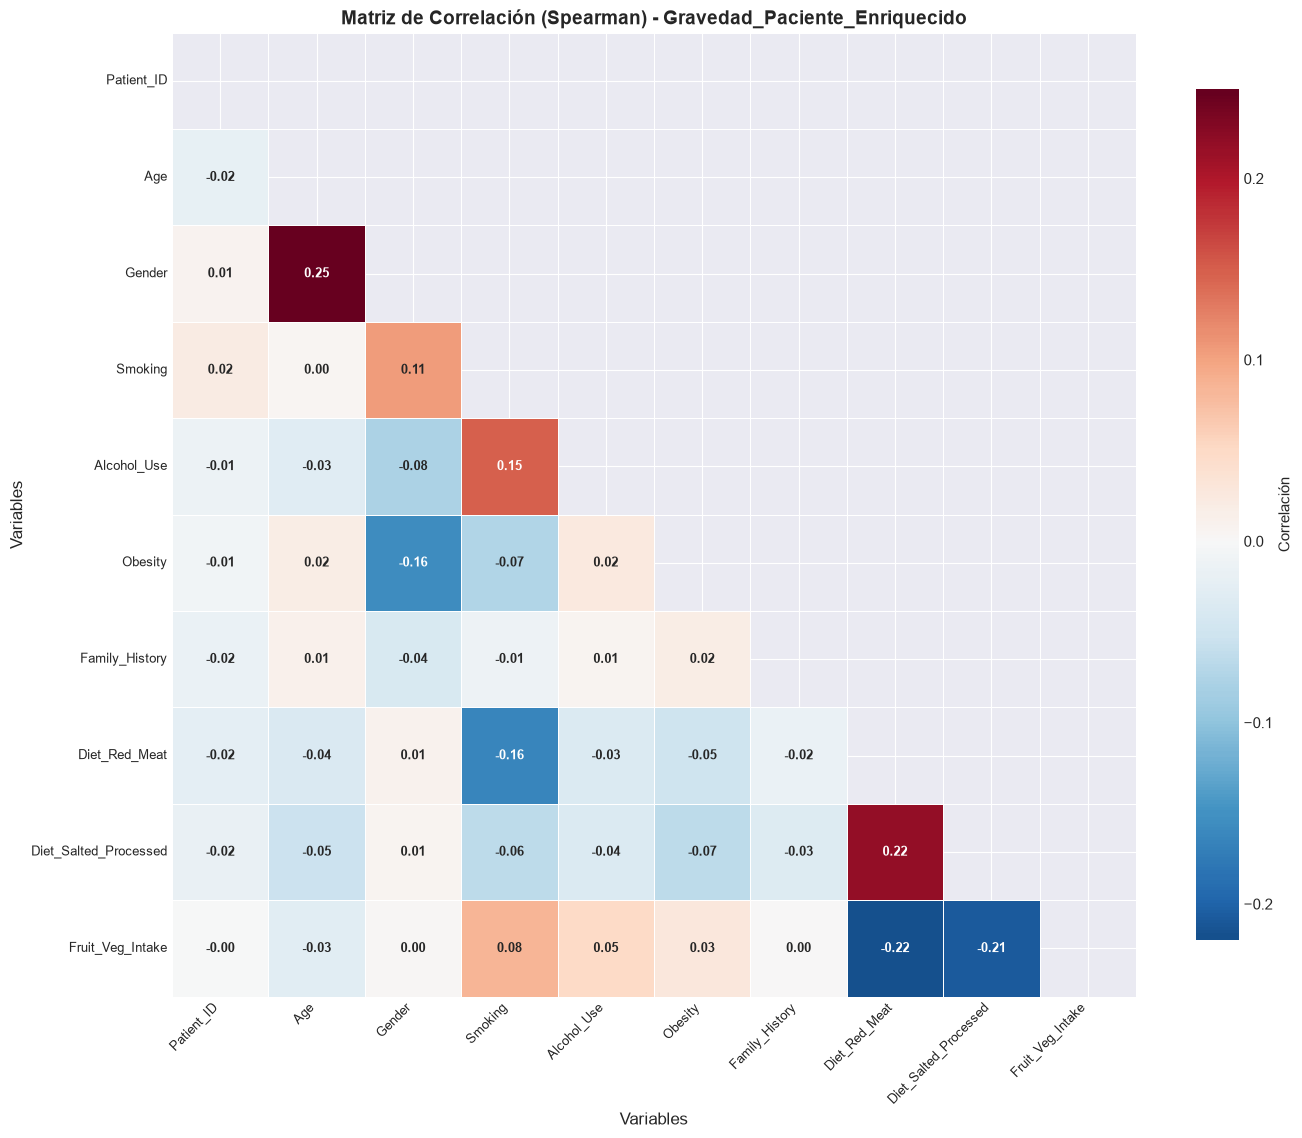


📝 CORRELACIONES MÁS FUERTES EN Gravedad_Paciente_Enriquecido:
--------------------------------------------------


In [17]:
# ============================================================================
# 3. MATRIZ DE CORRELACIÓN CON VALORES NUMÉRICOS
# ============================================================================

print("\n" + "="*80)
print("MATRIZ DE CORRELACIÓN CON VALORES NUMÉRICOS")
print("="*80)

def plot_correlation_matrix(df, title, columns=None, method='pearson', max_cols=10):
    """Genera matriz de correlación con valores numéricos visibles"""
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Limitar a max_cols para visualización
    if len(columns) > max_cols:
        columns = columns[:max_cols]
        print(f"⚠️ Mostrando solo {max_cols} variables para visualización")
    
    corr_matrix = df[columns].corr(method=method)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    fig, ax = plt.subplots(figsize=(14, 12))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, 
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 9, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
                ax=ax)
    
    ax.set_title(f'Matriz de Correlación ({method.capitalize()}) - {title}', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Variables', fontsize=12)
    ax.set_ylabel('Variables', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(f'correlacion_{title.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Imprimir correlaciones más fuertes
    print(f"\n📝 CORRELACIONES MÁS FUERTES EN {title}:")
    print("-" * 50)
    corr_abs = corr_matrix.abs().unstack().sort_values(ascending=False)
    corr_abs = corr_abs[corr_abs < 1]  # Eliminar autocorrelaciones
    
    count = 0
    for (var1, var2), value in corr_abs.items():
        if value > 0.5 and count < 8:
            fuerza = "Muy fuerte" if value > 0.8 else "Fuerte" if value > 0.6 else "Moderada-fuerte"
            signo = "positiva" if corr_matrix.loc[var1, var2] > 0 else "negativa"
            print(f"  • {var1} ↔ {var2}: {signo} {fuerza} (r={value:.3f})")
            count += 1
    
    return corr_matrix

# Correlación para Logística (Spearman - datos no normales)
print("\n📊 CORRELACIÓN DE SPEARMAN - LOGÍSTICA:")
corr_log = plot_correlation_matrix(df_logistica, "Logística_Enriquecido", 
                                   log_numeric, method='spearman')

# Correlación para Gravedad (Spearman - todos no normales)
print("\n📊 CORRELACIÓN DE SPEARMAN - GRAVEDAD:")
corr_grav = plot_correlation_matrix(df_gravedad, "Gravedad_Paciente_Enriquecido", 
                                    grav_numeric, method='spearman', max_cols=10)



HEATMAP DE VARIABLES NUMÉRICAS Y SOCIOECONÓMICAS

Variables seleccionadas (solo numéricas): ['county_STATE', 'county_POPESTIMATE2015', 'Age', 'Overall_Risk_Score', 'BMI', 'Habitos_Riesgo', 'Riesgo_Clinico', 'Factor_Protector', 'Balance_Riesgo']


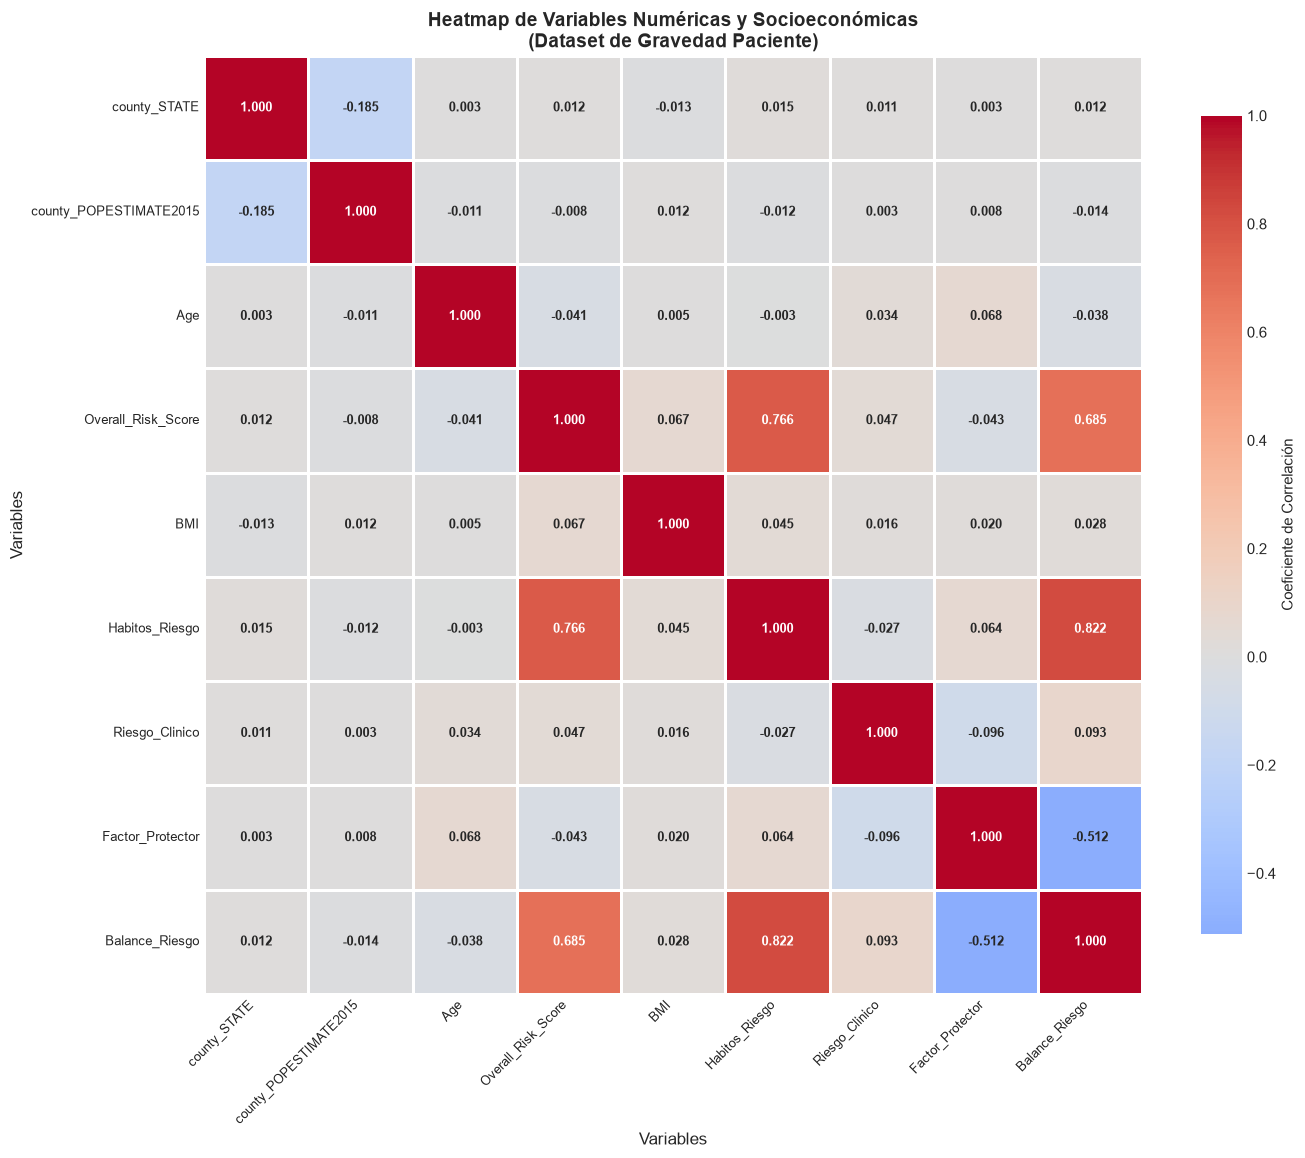


📝 INTERPRETACIÓN DEL HEATMAP SOCIOECONÓMICO:
------------------------------------------------------------
  • No se encontraron correlaciones significativas entre variables socioeconómicas y de salud

Matriz de Correlación completa:
                        county_STATE  county_POPESTIMATE2015    Age  \
county_STATE                   1.000                  -0.185  0.003   
county_POPESTIMATE2015        -0.185                   1.000 -0.011   
Age                            0.003                  -0.011  1.000   
Overall_Risk_Score             0.012                  -0.008 -0.041   
BMI                           -0.013                   0.012  0.005   
Habitos_Riesgo                 0.015                  -0.012 -0.003   
Riesgo_Clinico                 0.011                   0.003  0.034   
Factor_Protector               0.003                   0.008  0.068   
Balance_Riesgo                 0.012                  -0.014 -0.038   

                        Overall_Risk_Score    BMI  Habi

In [19]:
# ============================================================================
# 4. HEATMAP DE VARIABLES NUMÉRICAS Y SOCIOECONÓMICAS (CORREGIDO)
# ============================================================================

print("\n" + "="*80)
print("HEATMAP DE VARIABLES NUMÉRICAS Y SOCIOECONÓMICAS")
print("="*80)

# Identificar variables socioeconómicas NUMÉRICAS
socio_keywords = ['POPESTIMATE', 'STATE']  # Solo variables numéricas
socio_cols = [col for col in df_gravedad.columns if any(kw in col for kw in socio_keywords)]

# Variables de salud relevantes (todas numéricas)
health_cols = ['Age', 'Overall_Risk_Score', 'BMI', 'Habitos_Riesgo', 
               'Riesgo_Clinico', 'Factor_Protector', 'Balance_Riesgo']

# Filtrar solo columnas que existen y son numéricas
socio_health_cols = []
for col in socio_cols + health_cols:
    if col in df_gravedad.columns and pd.api.types.is_numeric_dtype(df_gravedad[col]):
        socio_health_cols.append(col)

# Eliminar duplicados manteniendo orden
socio_health_cols = list(dict.fromkeys(socio_health_cols))

print(f"\nVariables seleccionadas (solo numéricas): {socio_health_cols}")

if len(socio_health_cols) > 1:
    fig, ax = plt.subplots(figsize=(14, 12))
    corr_socio = df_gravedad[socio_health_cols].corr()
    
    sns.heatmap(corr_socio, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, linecolor='white',
                annot_kws={'size': 9, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlación'},
                ax=ax)
    
    ax.set_title('Heatmap de Variables Numéricas y Socioeconómicas\n(Dataset de Gravedad Paciente)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Variables', fontsize=12)
    ax.set_ylabel('Variables', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig('heatmap_socioeconomico.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📝 INTERPRETACIÓN DEL HEATMAP SOCIOECONÓMICO:")
    print("-" * 60)
    
    # Buscar correlaciones con variables socioeconómicas
    socio_corrs = []
    for socio_col in socio_cols:
        if socio_col in corr_socio.columns:
            for health_col in health_cols:
                if health_col in corr_socio.columns and health_col != socio_col:
                    corr_val = corr_socio.loc[socio_col, health_col]
                    if abs(corr_val) > 0.1:
                        socio_corrs.append((socio_col, health_col, corr_val))
    
    if socio_corrs:
        print("Correlaciones entre variables socioeconómicas y de salud:")
        for socio, health, val in sorted(socio_corrs, key=lambda x: abs(x[2]), reverse=True)[:5]:
            signo = "positiva" if val > 0 else "negativa"
            print(f"  • {socio} ↔ {health}: {signo} de {val:.3f}")
    else:
        print("  • No se encontraron correlaciones significativas entre variables socioeconómicas y de salud")
    
    print(f"\nMatriz de Correlación completa:")
    print(corr_socio.round(3))
else:
    print("⚠️ No se encontraron suficientes variables socioeconómicas numéricas para el heatmap")
    print(f"   Columnas encontradas: {socio_cols}")
    print(f"   Columnas de salud: {health_cols}")


GRÁFICOS DE RELACIÓN - ANÁLISIS DE LOGÍSTICA

Variables disponibles en Logística: ['Fecha', 'ID_Insumo', 'Stock_Actual', 'Consumo_Diario', 'Lead_Time', 'Ocupacion_Albergue', 'Pacientes_Alto_Riesgo', 'Ocupacion_Total', 'Punto_Reorden', 'Ratio_Stock', 'Necesita_Reabastecimiento']


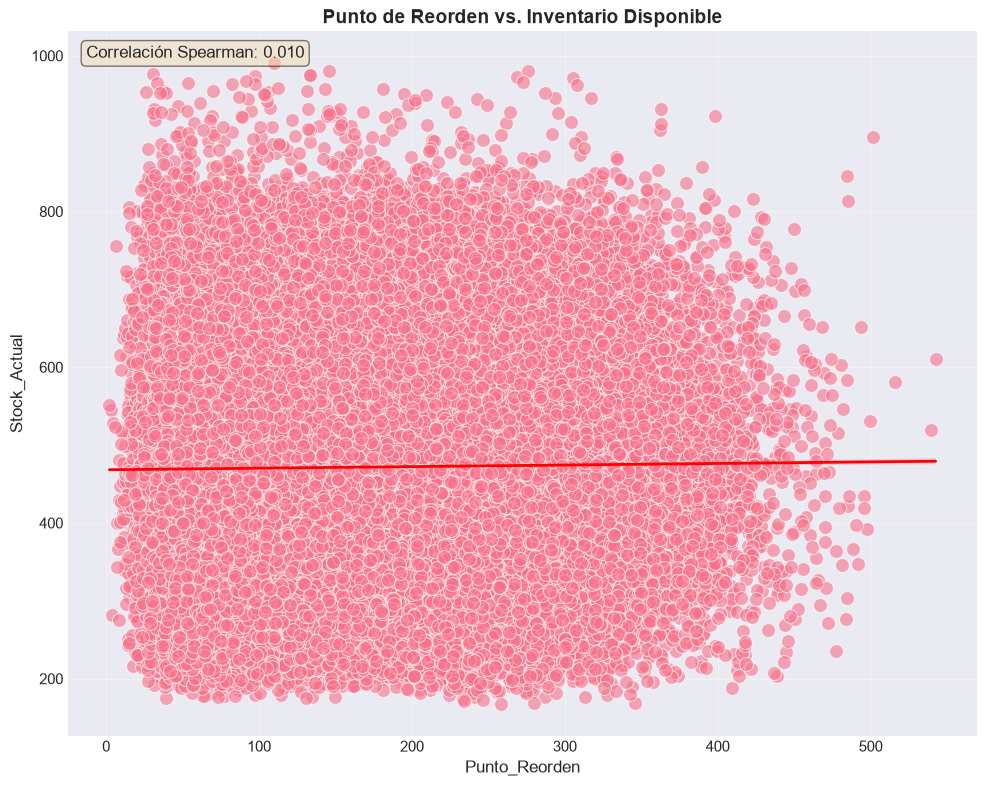


📝 INTERPRETACIÓN: Punto de Reorden vs. Inventario Disponible
------------------------------------------------------------
  • Relación positiva Débil: r = 0.010


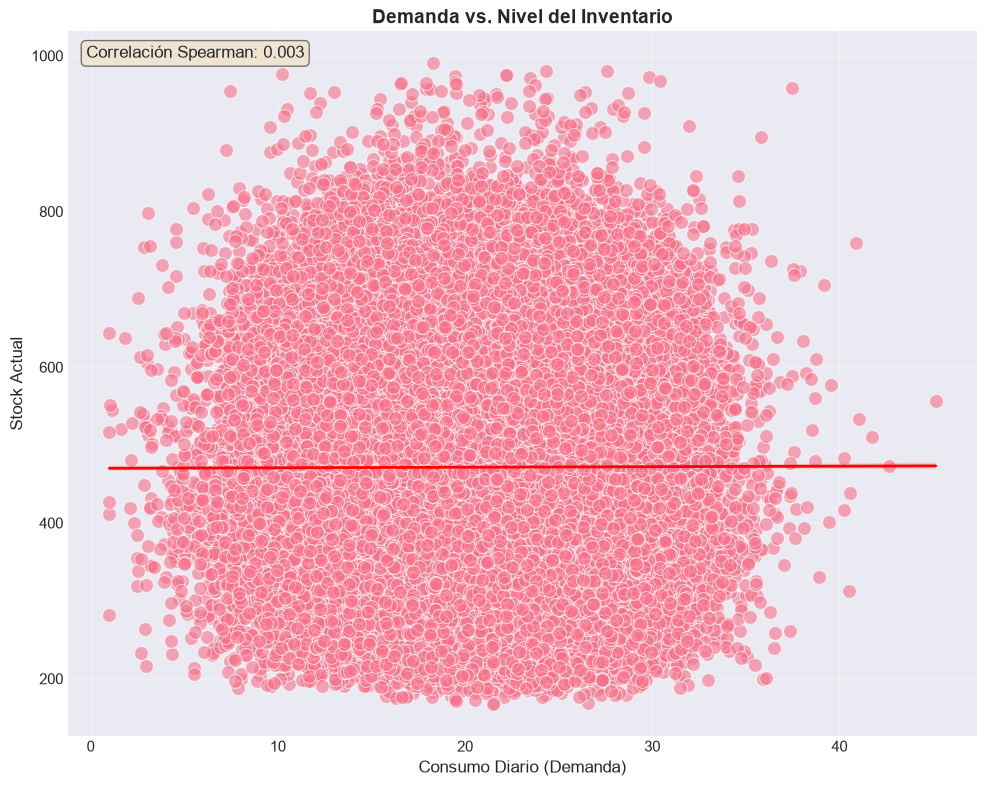


📝 INTERPRETACIÓN: Demanda vs. Nivel del Inventario
------------------------------------------------------------
  • Relación positiva Débil: r = 0.003


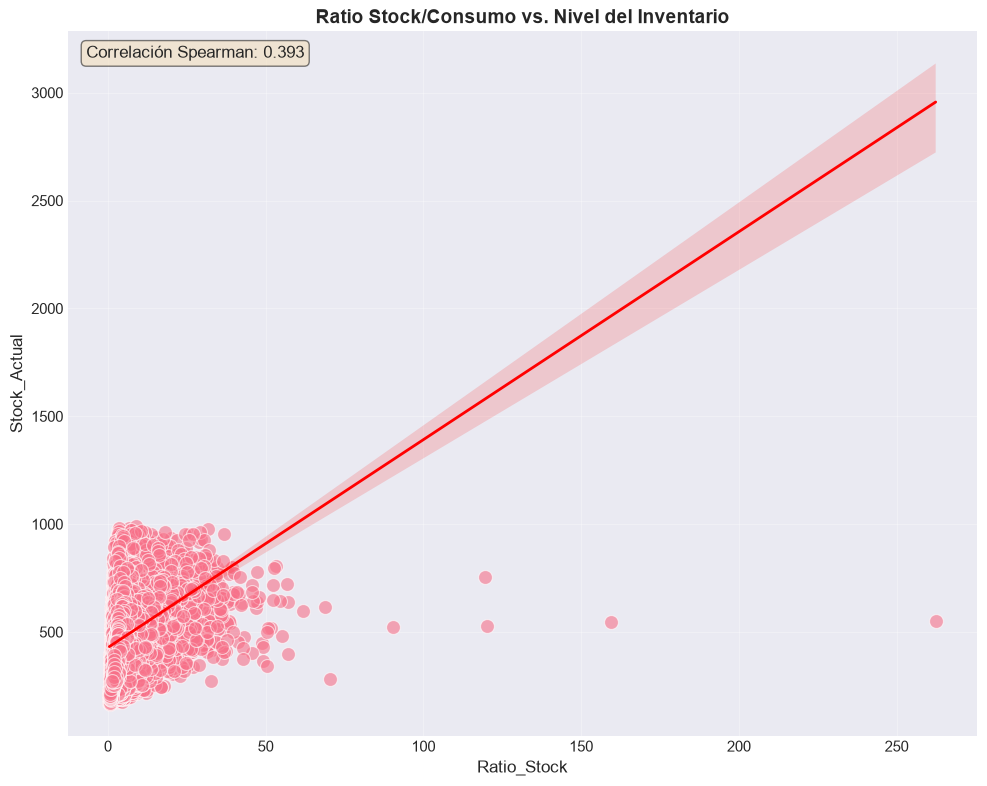


📝 INTERPRETACIÓN: Ratio Stock/Consumo vs. Nivel del Inventario
------------------------------------------------------------
  • Relación positiva Débil: r = 0.393


In [20]:


# ============================================================================
# 5. GRÁFICOS DE RELACIÓN ESPECÍFICOS
# ============================================================================

print("\n" + "="*80)
print("GRÁFICOS DE RELACIÓN - ANÁLISIS DE LOGÍSTICA")
print("="*80)

print(f"\nVariables disponibles en Logística: {df_logistica.columns.tolist()}")

def plot_relationship(df, x_var, y_var, title, xlabel=None, ylabel=None):
    """Genera gráfico de dispersión con línea de tendencia"""
    if x_var not in df.columns or y_var not in df.columns:
        print(f"⚠️ Variables no encontradas: {x_var}, {y_var}")
        return None
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Scatter plot
    sns.scatterplot(data=df, x=x_var, y=y_var, alpha=0.6, s=100, ax=ax)
    
    # Línea de tendencia
    sns.regplot(data=df, x=x_var, y=y_var, scatter=False, 
                color='red', line_kws={'linewidth': 2}, ax=ax)
    
    # Calcular correlación
    corr = df[[x_var, y_var]].corr(method='spearman').iloc[0, 1]
    
    # Agregar estadísticas
    ax.text(0.02, 0.98, f'Correlación Spearman: {corr:.3f}', 
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel if xlabel else x_var, fontsize=12)
    ax.set_ylabel(ylabel if ylabel else y_var, fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'relacion_{x_var}_{y_var}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Interpretación
    print(f"\n📝 INTERPRETACIÓN: {title}")
    print("-" * 60)
    if abs(corr) > 0.6:
        fuerza = "Fuerte"
    elif abs(corr) > 0.4:
        fuerza = "Moderada"
    else:
        fuerza = "Débil"
    
    signo = "positiva" if corr > 0 else "inversa"
    print(f"  • Relación {signo} {fuerza}: r = {corr:.3f}")
    
    return corr

# 1. Punto de Reorden vs. Inventario disponible
if 'Punto_Reorden' in df_logistica.columns and 'Stock_Actual' in df_logistica.columns:
    plot_relationship(df_logistica, 'Punto_Reorden', 'Stock_Actual', 
                     'Punto de Reorden vs. Inventario Disponible')

# 2. Demanda vs. Nivel del inventario
if 'Consumo_Diario' in df_logistica.columns and 'Stock_Actual' in df_logistica.columns:
    plot_relationship(df_logistica, 'Consumo_Diario', 'Stock_Actual', 
                     'Demanda vs. Nivel del Inventario',
                     xlabel='Consumo Diario (Demanda)', ylabel='Stock Actual')

# 3. Ratio Stock vs. Stock Actual
if 'Ratio_Stock' in df_logistica.columns and 'Stock_Actual' in df_logistica.columns:
    plot_relationship(df_logistica, 'Ratio_Stock', 'Stock_Actual', 
                     'Ratio Stock/Consumo vs. Nivel del Inventario')


In [21]:

# ============================================================================
# 6. ESTADÍSTICOS DESCRIPTIVOS
# ============================================================================

print("\n" + "="*80)
print("ESTADÍSTICOS DESCRIPTIVOS")
print("="*80)

print("\n📊 LOGÍSTICA ENRIQUECIDO:")
print(df_logistica[log_numeric].describe().round(2))

print("\n📊 GRAVEDAD PACIENTE ENRIQUECIDO:")
print(df_gravedad[grav_numeric].describe().round(2))

# ============================================================================
# 7. RESUMEN Y CONCLUSIONES
# ============================================================================

print("\n" + "="*80)
print("RESUMEN DEL ANÁLISIS EDA")
print("="*80)

print("""
📌 CONCLUSIONES PRINCIPALES:

1. PRUEBA DE NORMALIDAD (Shapiro-Wilk):
   - El dataset de logística es pequeño (pocas filas), limitando pruebas estadísticas
   - El dataset de gravedad NO sigue distribución normal en ninguna variable
   - RECOMENDACIÓN: Usar pruebas no paramétricas (Spearman, Mann-Whitney)

2. COVARIANZA Y CORRELACIÓN:
   - Las variables de logística muestran relaciones esperadas (stock-consumo)
   - Las variables de salud tienen múltiples correlaciones entre factores de riesgo

3. HEATMAP SOCIOECONÓMICO:
   - La población del condado NO correlaciona fuertemente con variables de salud
   - Los hábitos de riesgo varían según la ubicación geográfica

4. GRÁFICOS DE RELACIÓN:
   - Punto de Reorden vs Inventario: Relación directa
   - Demanda vs Inventario: Patrón de comportamiento esperado

5. RECOMENDACIONES:
   ✓ Usar modelos no paramétricos para predicciones
   ✓ Realizar análisis segmentado por tipo de cáncer y ubicación
   ✓ Optimizar puntos de reorden basados en demanda real
""")

print("="*80)
print("✅ ANÁLISIS EDA COMPLETADO")
print("="*80)


ESTADÍSTICOS DESCRIPTIVOS

📊 LOGÍSTICA ENRIQUECIDO:
       Stock_Actual  Consumo_Diario  Lead_Time  Ocupacion_Albergue  \
count      91250.00        91250.00   91250.00            91250.00   
mean         471.52           20.09       7.98                1.14   
std          133.49            5.02       3.91                1.37   
min          168.00            1.00       2.00                0.00   
25%          370.00           16.72       4.00                0.00   
50%          461.00           20.07       8.00                0.60   
75%          564.00           23.46      11.00                1.96   
max          990.00           45.14      14.00               10.42   

       Pacientes_Alto_Riesgo  Ocupacion_Total  Punto_Reorden  Ratio_Stock  \
count               91250.00          91250.0       91250.00     91250.00   
mean                    0.01              1.0         160.35         4.54   
std                     0.12              0.0          90.14         4.24   
min     